In [1]:
!pip install pandas matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
inventory = pd.DataFrame(columns=[
    "Item",
    "Category",
    "Quantity",
    "Min_Stock",
    "Expiry_Date"
])

inventory

,Item,Category,Quantity,Min_Stock,Expiry_Date


In [4]:
data = [

["Rice","Grains",5,2,"2026-08-20"],
["Milk","Dairy",1,2,"2026-06-03"],
["Bread","Bakery",1,2,"2026-06-02"],
["Eggs","Protein",12,6,"2026-06-10"],
["Tomato","Vegetable",2,3,"2026-06-04"]

]

inventory = pd.DataFrame(
data,
columns=[
"Item",
"Category",
"Quantity",
"Min_Stock",
"Expiry_Date"
])

inventory

,Item,Category,Quantity,Min_Stock,Expiry_Date
0,Rice,Grains,5,2,2026-08-20
1,Milk,Dairy,1,2,2026-06-03
2,Bread,Bakery,1,2,2026-06-02
3,Eggs,Protein,12,6,2026-06-10
4,Tomato,Vegetable,2,3,2026-06-04


In [12]:
inventory.to_csv(
    "inventory_file.csv",
    index=False
)

print("File Saved Successfully")

File Saved Successfully


In [13]:
from google.colab import files

files.download(
    "inventory_file.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
low_stock = inventory[
inventory["Quantity"] <= inventory["Min_Stock"]
]

print("LOW STOCK ITEMS")

print(low_stock[
["Item","Quantity"]
])

LOW STOCK ITEMS
     Item  Quantity
1    Milk         1
2   Bread         1
4  Tomato         2


In [6]:
inventory["Expiry_Date"] = pd.to_datetime(
inventory["Expiry_Date"]
)

today = pd.Timestamp.today()

inventory["Days_Left"] = (
inventory["Expiry_Date"] - today
).dt.days

expiry = inventory[
inventory["Days_Left"] <= 5
]

print("EXPIRING SOON")

print(expiry[
["Item","Days_Left"]
])

EXPIRING SOON
     Item  Days_Left
1    Milk          2
2   Bread          1
4  Tomato          3


In [7]:
shopping = low_stock["Item"]

print("SHOPPING LIST")

for item in shopping:
    print("-", item)

SHOPPING LIST
- Milk
- Bread
- Tomato


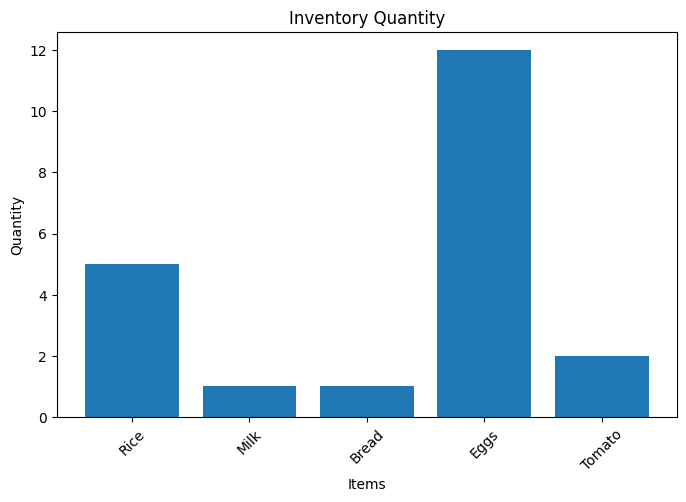

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
inventory["Item"],
inventory["Quantity"]
)

plt.title(
"Inventory Quantity"
)

plt.xlabel(
"Items"
)

plt.ylabel(
"Quantity"
)

plt.xticks(rotation=45)

plt.show()

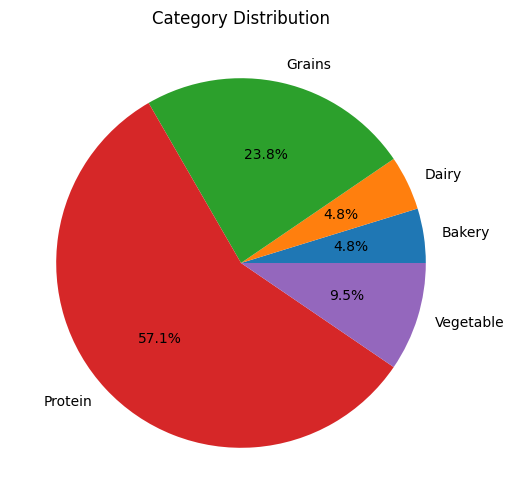

In [9]:
category = inventory.groupby(
"Category"
)["Quantity"].sum()

plt.figure(figsize=(6,6))

plt.pie(
category,
labels=category.index,
autopct="%1.1f%%"
)

plt.title(
"Category Distribution"
)

plt.show()

In [10]:
inventory.to_csv(
"inventory_data.csv",
index=False
)

print(
"File Saved Successfully"
)

File Saved Successfully


In [11]:
from google.colab import files

files.download(
"inventory_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>